<a href="https://colab.research.google.com/github/Cognitioneer/LLM-Inference/blob/main/kv_cache_from_scratch_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Understanding the KV Cache from scratch (visual edition)

When a transformer generates text one token at a time, it attends over **every previous token** at each step. The naive approach recomputes the Keys and Values for all of those tokens on every step — wasted work, because past tokens never change.

The **KV cache** computes each token's Key and Value *once*, stores them, and reuses them. This notebook builds that idea up and **draws every step**:

1. Generate the **slow way** (recompute K, V each step) vs **with a cache**
2. **Verify** they're identical
3. **See** the recompute pattern as heatmaps
4. **Plot** the O(T²) vs O(T) work growth
5. **Plot** the cache's memory growth for real models
6. Inspect a real model (**GPT-2**) and **visualize the outlier channels** that motivate **KIVI**

Runs on a free Colab CPU runtime, top to bottom.

## 1. Setup

In [1]:
import math, time
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("torch", torch.__version__)

torch 2.11.0+cu128


## 2. The problem: autoregressive generation

To produce token *t*, the attention layer needs a **query** `q_t` for the current token plus the **keys** and **values** for all tokens `0 ... t`:

$$\text{out}_t = \text{softmax}\!\left(\frac{q_t K^\top}{\sqrt{d}}\right) V$$

The keys and values for tokens `0 ... t-1` are identical at every step — recomputing them is pure waste. Let's make that visible.

## 3. A tiny single-head attention layer

In [3]:
d_model = 16   # hidden size per token
d_head  = 16   # single attention head

Wq = torch.randn(d_model, d_head) * 0.1
Wk = torch.randn(d_model, d_head) * 0.1
Wv = torch.randn(d_model, d_head) * 0.1

T = 6
hidden = torch.randn(T, d_model)   # pretend a prior layer produced these
print("hidden states [tokens, d_model]:", tuple(hidden.shape))

hidden states [tokens, d_model]: (6, 16)


## 4. Generation the slow way (NO cache)

In [4]:
def generate_no_cache(hidden):
    outputs, proj_count = [], 0
    for t in range(hidden.shape[0]):
        x = hidden[: t + 1]              # ALL tokens so far
        K = x @ Wk                       # recompute K for every token...
        V = x @ Wv                       # ...and V too -> the waste
        proj_count += 2 * x.shape[0]
        q = hidden[t : t + 1] @ Wq       # query for current token only
        scores = q @ K.T / math.sqrt(d_head)
        out = torch.softmax(scores, dim=-1) @ V
        outputs.append(out)
    return torch.cat(outputs, 0), proj_count

out_slow, proj_slow = generate_no_cache(hidden)
print("output shape:", tuple(out_slow.shape), "| K/V projections:", proj_slow)

output shape: (6, 16) | K/V projections: 42


## 5. Generation WITH a KV cache

In [5]:
def generate_with_cache(hidden):
    outputs, K_cache, V_cache, proj_count = [], [], [], 0
    for t in range(hidden.shape[0]):
        x_t = hidden[t : t + 1]          # only the NEW token
        K_cache.append(x_t @ Wk)         # project once, store
        V_cache.append(x_t @ Wv)
        proj_count += 2
        K = torch.cat(K_cache, 0)        # reuse all past K, V
        V = torch.cat(V_cache, 0)
        q = x_t @ Wq
        scores = q @ K.T / math.sqrt(d_head)
        out = torch.softmax(scores, dim=-1) @ V
        outputs.append(out)
    return torch.cat(outputs, 0), proj_count

out_fast, proj_fast = generate_with_cache(hidden)
print("output shape:", tuple(out_fast.shape), "| K/V projections:", proj_fast)

output shape: (6, 16) | K/V projections: 12


## 6. Are they the same?

The cache must change *nothing* about the result.

In [6]:
print("identical outputs:", torch.allclose(out_slow, out_fast, atol=1e-6))
print("max difference   :", (out_slow - out_fast).abs().max().item())

identical outputs: True
max difference   : 6.705522537231445e-08


## 7. Visualize what gets recomputed

Each grid below has **generation steps** down the rows and **token positions** across the columns. A filled cell means "this token's K/V was computed at this step."

- **No cache (left):** the whole lower triangle lights up — every past token is recomputed at every step.
- **With cache (right):** only the diagonal lights up — each token is computed exactly once.

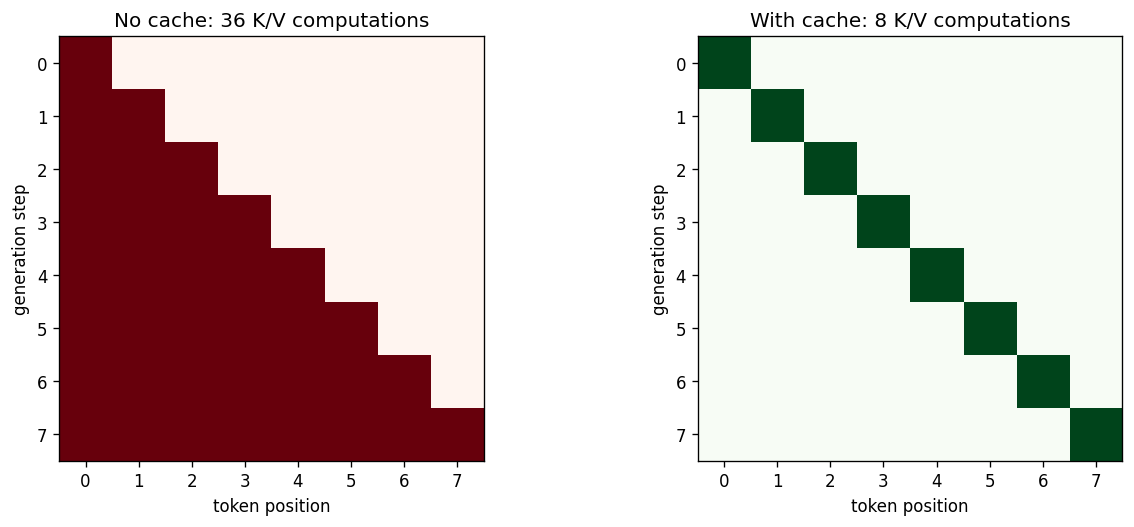

In [7]:
T = 8
no_cache_pattern = np.zeros((T, T))
cache_pattern    = np.zeros((T, T))
for step in range(T):
    no_cache_pattern[step, : step + 1] = 1   # recompute all past tokens
    cache_pattern[step, step] = 1            # compute only the new token

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, data, title, cmap in [
    (axes[0], no_cache_pattern, f"No cache: {int(no_cache_pattern.sum())} K/V computations", "Reds"),
    (axes[1], cache_pattern,    f"With cache: {int(cache_pattern.sum())} K/V computations", "Greens"),
]:
    ax.imshow(data, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("token position")
    ax.set_ylabel("generation step")
    ax.set_xticks(range(T)); ax.set_yticks(range(T))
    ax.grid(False)
plt.tight_layout(); plt.show()

## 8. How the work grows

No cache recomputes a growing triangle → total work scales like **O(T²)**.
A cache does one new token per step → **O(T)**. Watch the gap on a log scale.

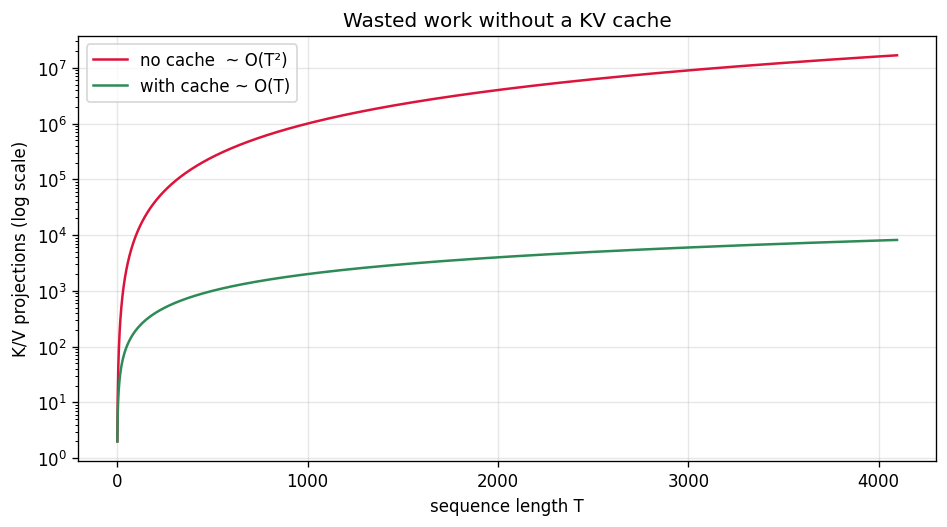

T=   8: no-cache=        72  cache=    16
T= 512: no-cache=    262656  cache=  1024
T=4096: no-cache=  16781312  cache=  8192


In [8]:
Ts = np.arange(1, 4097)
work_no_cache = 2 * Ts * (Ts + 1) / 2   # 2 * sum(1..T)
work_cache    = 2 * Ts

plt.figure(figsize=(8, 4.5))
plt.plot(Ts, work_no_cache, label="no cache  ~ O(T²)", color="crimson")
plt.plot(Ts, work_cache,    label="with cache ~ O(T)", color="seagreen")
plt.yscale("log")
plt.xlabel("sequence length T")
plt.ylabel("K/V projections (log scale)")
plt.title("Wasted work without a KV cache")
plt.legend(); plt.tight_layout(); plt.show()

for L in [8, 512, 4096]:
    print(f"T={L:>4}: no-cache={int(2*L*(L+1)//2):>10}  cache={2*L:>6}")

## 9. The memory cost of the cache

The cache trades compute for **memory** — a Key and Value vector per token, per layer, per head, per batch item:

$$\text{cache size} = 2 \times n_\text{layers}\times n_\text{kv heads}\times d_\text{head}\times \text{seq}\times \text{batch}\times \text{bytes}$$

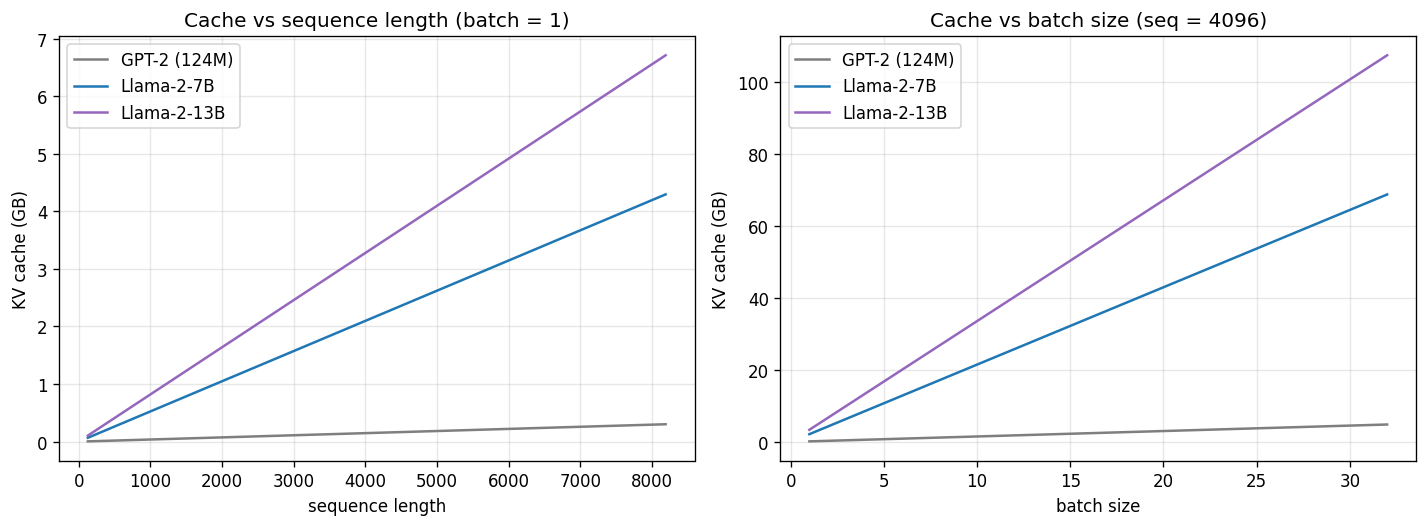

In [9]:
def kv_cache_bytes(n_layers, n_kv_heads, head_dim, seq_len, batch=1, bytes_per=2):
    return 2 * n_layers * n_kv_heads * head_dim * seq_len * batch * bytes_per

models = {                       # (layers, kv_heads, head_dim)
    "GPT-2 (124M)": (12, 12,  64),
    "Llama-2-7B":   (32, 32, 128),
    "Llama-2-13B":  (40, 40, 128),
}
colors = {"GPT-2 (124M)": "tab:gray", "Llama-2-7B": "tab:blue", "Llama-2-13B": "tab:purple"}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))

seqs = np.arange(128, 8193, 128)
for name, (L, H, D) in models.items():
    axL.plot(seqs, [kv_cache_bytes(L, H, D, s) / 1e9 for s in seqs], label=name, color=colors[name])
axL.set_xlabel("sequence length"); axL.set_ylabel("KV cache (GB)")
axL.set_title("Cache vs sequence length (batch = 1)"); axL.legend()

batches = np.arange(1, 33)
for name, (L, H, D) in models.items():
    axR.plot(batches, [kv_cache_bytes(L, H, D, 4096, b) / 1e9 for b in batches], label=name, color=colors[name])
axR.set_xlabel("batch size"); axR.set_ylabel("KV cache (GB)")
axR.set_title("Cache vs batch size (seq = 4096)"); axR.legend()
plt.tight_layout(); plt.show()

A single Llama-2-7B sequence of 4096 tokens already needs ~2 GB of cache, and it grows **linearly with batch size** — at batch 16 that's ~32 GB, often larger than the weights. This is the bottleneck **KIVI** attacks by quantizing the cache to ~2 bits.

## 10. The cache inside a real model (GPT-2)

HuggingFace exposes the cache as `past_key_values`. Load GPT-2, run one forward pass, inspect the shapes.

In [19]:
# WHAT: install HuggingFace Transformers (Colab doesn't ship it).
# WHY: we want to inspect a *real* model's KV cache, not just our toy one.
!pip install -q transformers
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# WHAT: load the tokenizer (text <-> integer token ids).
# WHY: the model operates on token ids, not raw strings.
tok = GPT2Tokenizer.from_pretrained("gpt2")

# WHAT: load GPT-2's weights, put it in eval mode.
# WHY eval(): disables dropout so the forward pass is deterministic — we're inspecting, not training.
model = GPT2LMHeadModel.from_pretrained("gpt2").eval()

# WHAT: a sample sentence.
# WHY: we need real tokens so the cache actually has keys/values to look at.
text = "The quick brown fox jumps over the lazy dog while the cache stores keys and values"

# WHAT: tokenize into a tensor of shape [batch=1, seq_len].
# WHY return_tensors="pt": the model wants PyTorch tensors as input.
ids = tok(text, return_tensors="pt").input_ids

# WHAT: run ONE forward pass with caching on.
# WHY no_grad(): inference only — skip gradient tracking to save time/memory.
# WHY use_cache=True: tells the model to BUILD and return the KV cache (past_key_values) — the thing we want.
with torch.no_grad():
    out = model(ids, use_cache=True)

# WHAT: helper to pull one layer's Key/Value tensors out of the cache.
# WHY it exists: HuggingFace changed the cache object across versions, so we try newest -> oldest APIs.
def get_kv(pkv, layer):
    # each stored tensor is [batch, heads, seq, head_dim]; [0] drops the batch dim -> [heads, seq, head_dim].
    if hasattr(pkv, "layers"):                    # newest: DynamicCache.layers[i].keys/.values
        lyr = pkv.layers[layer]
        return lyr.keys[0], lyr.values[0]
    if hasattr(pkv, "key_cache"):                 # mid versions: .key_cache / .value_cache lists
        return pkv.key_cache[layer][0], pkv.value_cache[layer][0]
    return pkv[layer][0][0], pkv[layer][1][0]      # legacy tuple-of-tuples

# WHAT: the cache — one set of keys/values per transformer layer.
pkv = out.past_key_values

# WHAT: grab layer 0's cached K/V so we can read off the shape.
k0, v0 = get_kv(pkv, 0)

# WHAT: number of layers = number of separate K/V caches.
# WHY from config (not len(pkv)): the cache reports its length lazily, so config is the reliable count.
print("layers in cache:", model.config.n_layer)

# WHAT: the shape that matters — [heads, seq, head_dim].
# WHY: this is the per-layer cache. heads x head_dim, times layers, times tokens = the memory from section 9.
print("per-layer Key shape [heads, seq, head_dim]:", tuple(k0.shape))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

layers in cache: 12
per-layer Key shape [heads, seq, head_dim]: (12, 16, 64)


## 11. The outlier structure KIVI exploits

This is the empirical observation behind KIVI. We flatten the cache to `[tokens, channels]` (channels = every head × head_dim feature) and look at the magnitude of each value.

- **Keys:** a few **channels** are consistently huge across all tokens — vertical stripes in the heatmap, spikes in the per-channel curve. Quantizing *across* a row would let these outliers wreck the scale, so KIVI quantizes Keys **per-channel**.
- **Values:** no fixed-channel pattern — magnitudes are spread out, so **per-token** grouping is fine.

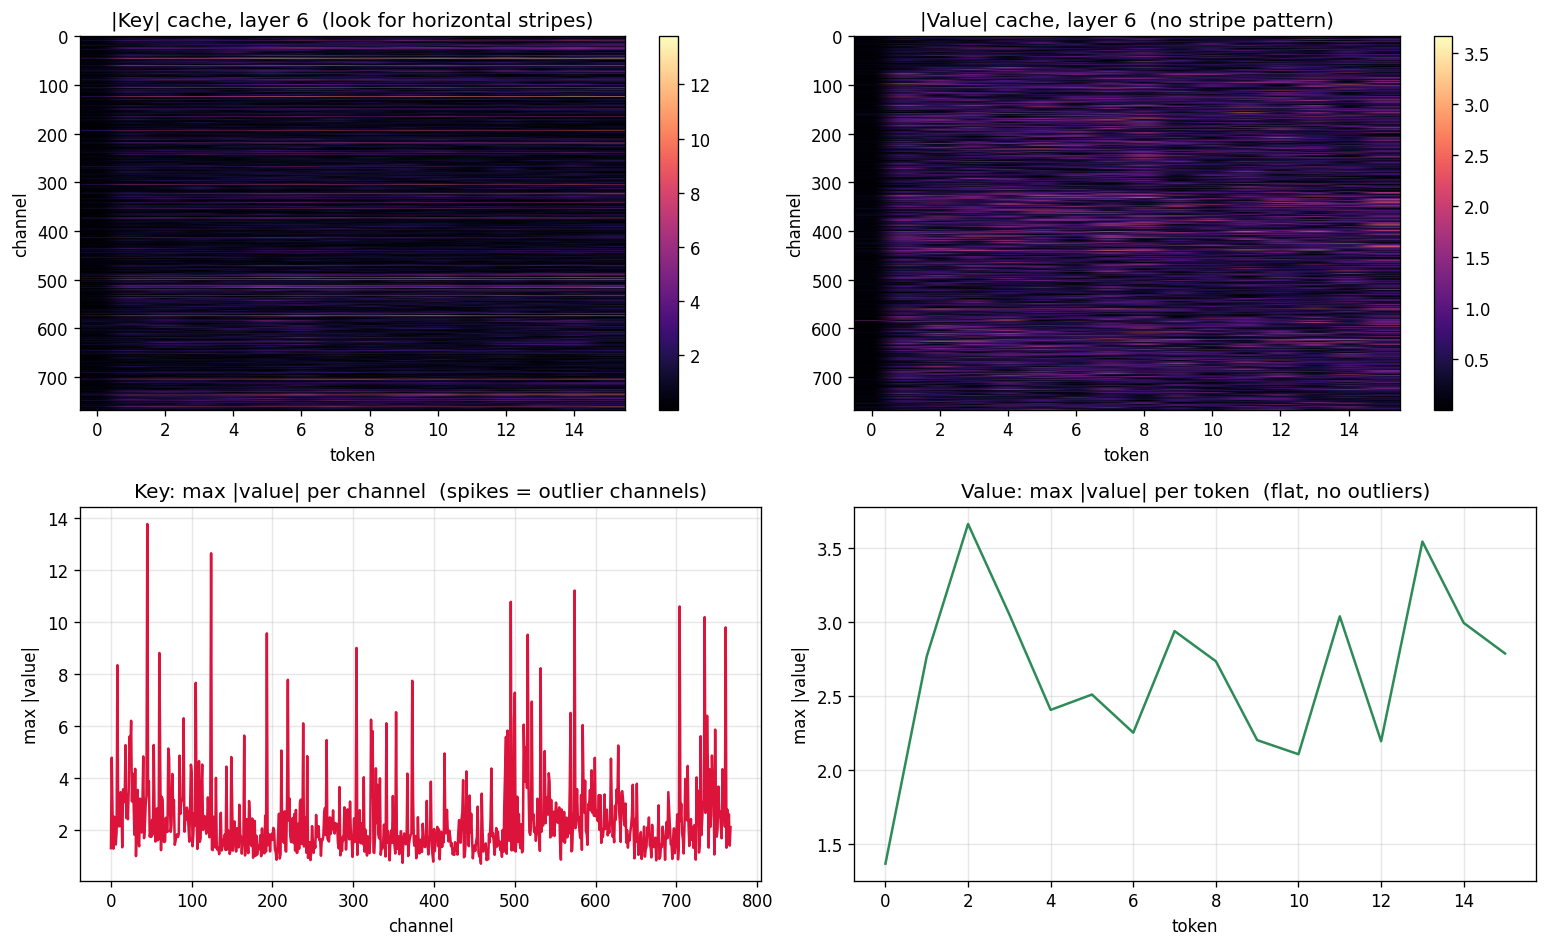

Key  per-channel max ranges from 0.72 to 13.78  (ratio 19.1x)
Value per-token  max ranges from 1.37 to 3.66  (ratio 2.7x)


In [20]:
layer = 6
K, V = get_kv(pkv, layer)                          # [heads, seq, head_dim]
Kc = K.permute(1, 0, 2).reshape(K.shape[1], -1).abs().detach().numpy()  # [tokens, channels]
Vc = V.permute(1, 0, 2).reshape(V.shape[1], -1).abs().detach().numpy()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

im0 = axes[0, 0].imshow(Kc.T, aspect="auto", cmap="magma")
axes[0, 0].set_title(f"|Key| cache, layer {layer}  (look for horizontal stripes)")
axes[0, 0].set_xlabel("token"); axes[0, 0].set_ylabel("channel"); axes[0, 0].grid(False)
fig.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(Vc.T, aspect="auto", cmap="magma")
axes[0, 1].set_title(f"|Value| cache, layer {layer}  (no stripe pattern)")
axes[0, 1].set_xlabel("token"); axes[0, 1].set_ylabel("channel"); axes[0, 1].grid(False)
fig.colorbar(im1, ax=axes[0, 1])

axes[1, 0].plot(Kc.max(axis=0), color="crimson")
axes[1, 0].set_title("Key: max |value| per channel  (spikes = outlier channels)")
axes[1, 0].set_xlabel("channel"); axes[1, 0].set_ylabel("max |value|")

axes[1, 1].plot(Vc.max(axis=1), color="seagreen")
axes[1, 1].set_title("Value: max |value| per token  (flat, no outliers)")
axes[1, 1].set_xlabel("token"); axes[1, 1].set_ylabel("max |value|")

plt.tight_layout(); plt.show()

print(f"Key  per-channel max ranges from {Kc.max(0).min():.2f} to {Kc.max(0).max():.2f}  "
      f"(ratio {Kc.max(0).max()/Kc.max(0).min():.1f}x)")
print(f"Value per-token  max ranges from {Vc.max(1).min():.2f} to {Vc.max(1).max():.2f}  "
      f"(ratio {Vc.max(1).max()/Vc.max(1).min():.1f}x)")

## 12. Cached generation is faster

Same output, very different speed. (On CPU the gap is modest; on GPU and longer sequences it's dramatic.)

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


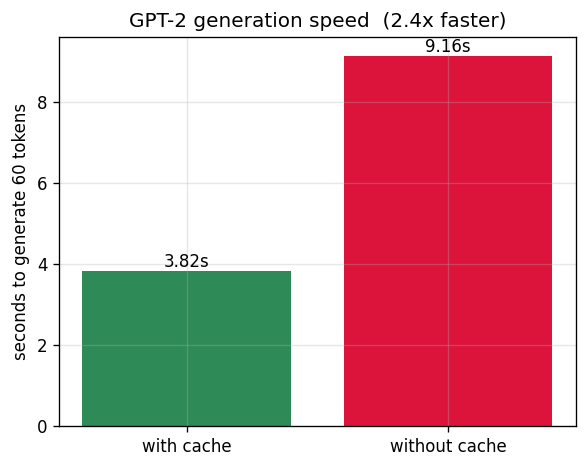

In [21]:
def time_generation(use_cache, n_new=60):
    t0 = time.time()
    with torch.no_grad():
        model.generate(ids, max_new_tokens=n_new, use_cache=use_cache,
                        do_sample=False, pad_token_id=tok.eos_token_id)
    return time.time() - t0

t_cache, t_no_cache = time_generation(True), time_generation(False)

plt.figure(figsize=(5, 4))
bars = plt.bar(["with cache", "without cache"], [t_cache, t_no_cache],
               color=["seagreen", "crimson"])
plt.ylabel("seconds to generate 60 tokens")
plt.title(f"GPT-2 generation speed  ({t_no_cache / t_cache:.1f}x faster)")
for b, v in zip(bars, [t_cache, t_no_cache]):
    plt.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}s", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 13. Where this connects to KIVI

You've now *seen* the whole tradeoff:

- **No cache:** little memory, O(T²) wasted compute → slow (sections 7–8).
- **With cache:** O(T) compute, but memory grows with `layers × heads × seq × batch` → the real bottleneck (section 9).

KIVI keeps the cache and **quantizes it to ~2 bits**, treating Keys and Values differently because of exactly the structure you plotted in section 11:

- **Keys → per-channel** (isolate the outlier channels you saw as stripes/spikes).
- **Values → per-token** (no outlier pattern; new tokens arrive one at a time anyway).
- A small **full-precision sliding window** of the newest tokens protects accuracy on hard reasoning tasks.

**Extension:** replace the fp16 cache in section 5 with a fake-quantized 2-bit version — per-channel for K, per-token for V — and re-plot the output error. That turns this into a working mini-KIVI.